# 第4回：群知能と粒子群最適化（PSO）

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rsimd/NITIC-ConbinatorialOptimization/blob/master/lecture04_pso.ipynb)

このノートでは、まず **群知能** の概要を述べ、つづいて **粒子群最適化（PSO）** を、直感・アルゴリズムの流れ・式・図・コードの順で整理する。

**PSO の本文（[第3節「粒子群最適化（PSO）」](#sec-pso-ch3)）** は、次の公開資料の用語・構成・式の形を **主たる参照** とする。詳細な理論・図表・PDF はこのページから辿れる。

- [粒子群最適化（PSO）— jkushida/ai-arch](https://jkushida.github.io/ai-arch/docs/pso_summary.html)

---


## 0. このノートで学ぶこと

1. **群知能**とは何か。単純な局所ルールが、集団としてどのように「探索（exploration）」と「開拓（exploitation）」のバランスを生むか。
2. **ACO** や **Bat Algorithm** など、群知能系アルゴリズムの **役割の違い**（何を状態にして、何を更新するか）。
3. **PSO** において、各粒子が持つ **位置・速度・パーソナルベスト・グローバルベスト** の意味。
4. 速度更新式の **三つの項（慣性・認知・社会）** がベクトルとしてどう合成されるか、および **主要パラメータ** が挙動に与える影響のイメージ。
5. アルゴリズムの **処理の流れ**（初期化から終了まで）と、簡単な **可視化コード** の読み方。
6. **PySwarms** の `BinaryPSO` を用いて、Wine データセットで **SVM の特徴選択** を試す流れ。
7. 同じく `BinaryPSO` で **0-1 ナップザック問題** を解く流れ（可行解と目的値の扱い）。
8. **GlobalBestPSO**（連続ベクトル PSO）で Wine の **SVM ハイパーパラメータ** （$\log_{10} C$、$\log_{10}\gamma$）を探索する流れ。

---


(sec:pso-ch1)=

## 1. 群知能（Swarm Intelligence）とは

**群知能**とは、各エージェントが従うルールは局所的・単純でも、相互作用を通じて、集団全体として「広く探す」「有望な場所を深く掘る」といった、一個体だけでは得にくい振る舞いが現れる現象や、そのモデル化アプローチを指す。鳥や魚の群れ、あるいはアリの経路選択など、自然界の集団行動がヒントになっていることが多い。

### メタヒューリスティクスとしての位置づけ

[第1回のメタヒューリスティクス](lecture01_intro_optimization.md) の枠組みと同様、群知能に基づく手法も **問題専用の厳密解法ではない**。目的関数の形を細かく利用しない **ブラックボックス探索** に強いものも多く、勾配が使えない・定義がごちゃごちゃしている、といった場面で選ばれることがある。一方で **最適解の保証は一般にない** ので、パラメータ設定や解の表現（順列か連続ベクトルか等）が結果を大きく左右する。

### 「探索」と「開拓」

群知能系の探索では、次の二つのバランスが説明の中心になりやすい。

- **探索（exploration）**：まだ十分に調べていない領域へ、粒子やエージェントを散らして広く当たること。
- **開拓（exploitation）**：すでに良い評価が出ている付近を、細かく調べて解を磨くこと。

探索だけだと局所解の周りを浅くかすめるだけになり、開拓だけだと初期付近や最初に見つかった谷に張り付きやすい。PSO は **自分の過去最良（パーソナルベスト）** と **集団の最良（グローバルベスト）** を組み合わせることで、この二つを同時に扱おうとする設計になっている（詳細は [第3節](#sec-pso-ch3)）。

### 群知能系アルゴリズムに共通しやすい構造

- **集団**：同時に複数の候補を維持する（多点探索）。
- **情報の共有**：全体最良や近傍の情報など、限定されたチャネルで他個体の知見に触れる。
- **単純な更新則**：1ステップあたりの計算は軽いことが多く、実装しやすい。

---


### 群れのイメージ（静止図）

下の図は物理シミュレーションではないが、「多数の点が、中心付近の『惹きつけ』へ向かって寄っていく」様子をイメージするためのスケッチである。群知能アルゴリズムでは、**個々の更新は単純でも、集団として谷（良い解の周辺）へ流れ込む** ことがある、という視覚的なたとえとして読んでほしい。

コードセルを実行すると図が表示される。



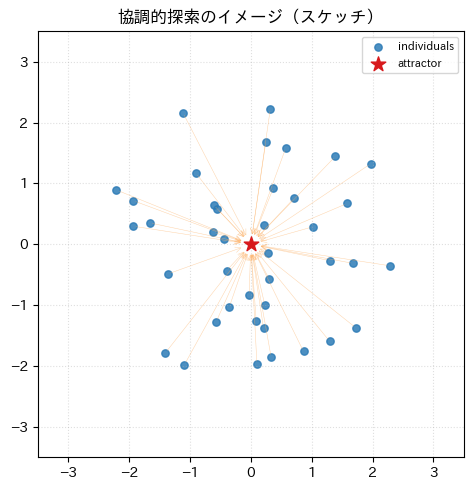

In [1]:
"""群知能の概念的イメージ：多数の個体が局所規則に従いながら集まる様子を簡略可視化する。"""

import matplotlib.pyplot as plt
import numpy as np

# 日本語ラベルを可能なら有効にする（プロジェクト依存: matplotlib-fontja）
try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    plt.rcParams["font.family"] = "sans-serif"


def plot_swarm_concept() -> None:
    rng = np.random.default_rng(seed=42)
    n = 40
    theta = rng.uniform(0, 2 * np.pi, size=n)
    r = rng.uniform(0.3, 2.8, size=n)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    goal = np.array([0.0, 0.0])

    _, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x, y, c="#2c7bb6", s=28, alpha=0.85, label="individuals")
    ax.scatter(goal[0], goal[1], c="#d7191c", s=120, marker="*", zorder=5, label="attractor")
    for i in range(n):
        ax.annotate("", xy=goal + 0.12 * np.array([x[i], y[i]]) / np.hypot(x[i], y[i] + 1e-9), xytext=(x[i], y[i]), arrowprops=dict(arrowstyle="->", color="#fdae61", lw=0.35, alpha=0.55))
    ax.set_aspect("equal")
    ax.set_title("協調的探索のイメージ（スケッチ）")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_swarm_concept()


## 2. 群知能アルゴリズムの例（名前と役割）

ここでは手順の細部は省略し、**何を状態変数に持ち、何を更新しているか** を文章で掴む。[第3節](#sec-pso-ch3) で主参照とする [jkushida の PSO まとめ](https://jkushida.github.io/ai-arch/docs/pso_summary.html) では、ACO 等との対比も含めて群知能最適化が整理されている。

### アリコロニー最適化（ACO: Ant Colony Optimization）

**着想**：アリは歩いた辺に **フェロモン** を残し、後続のアリはフェロモンが濃い辺を通りやすい。短い経路ほど往復が速く、同じ時間に多くのアリが通るため、結果として最短経路付近にフェロモンが蓄積しやすい、という **正のフィードバック** を利用する。

**蒸発などの工夫**：フェロモンが減衰すると、昔の成功体験に縛られにくくなり、別の経路を試しやすくなる。探索と開拓のバランスを、蒸発率やヒューリスティック情報で調整する。

**向きやすい問題**：グラフ上の **順路・順序** を決める **組合せ最適化**（配送ルーティングの近似など）。

### コウモリアルゴリズム（BA: Bat Algorithm）

**着想**：コウモリの **ソナー（エコロケーション）** にたとえ、各個体（コウモリ）が **位置と速度** を更新しながら解空間を動く。周波数や音量のメタファで、大域的な飛翔と局所的な近傍探索を切り替える、といった説明がされることが多い。

**注意**：生物の忠実な再現より、**連続最適化向けのヒューリスティクス** として理解するのが実用的である。

### ほかの例（参考）

| 名前 | 一言 |
| --- | --- |
| **PSO**（[第3節](#sec-pso-ch3)） | 連続ベクトルを粒子として動かし、pbest/gbest で引き合う |
| ホタル・ミツバチ系（FA, ABC など） | 光や蜜源スコアに応じた吸引・採用ルール |
| 細菌収斂など | 別の生物比喩に基づく群系メタヒューリスティクス |

手法名を暗記するより、**解の表現（順列・実数ベクトル・グラフ）** と問題の性質に合わせて枠組みを選ぶことが重要である。

---


(sec:pso-ch3)=

## 3. 粒子群最適化（Particle Swarm Optimization, PSO）

本節は、主として次の資料の構成と用語に合わせて書く（より詳しい理論・図表・PDF へのリンクもここから辿れる）。

- [粒子群最適化（PSO）— jkushida/ai-arch](https://jkushida.github.io/ai-arch/docs/pso_summary.html)

### 3.0 概要と起源

**粒子群最適化（PSO）** は、1995 年頃に James Kennedy と Russell Eberhart らによって提案された、群知能に基づく最適化アルゴリズムである。学術的な出発点は彼らの論文にあり、鳥や魚の **群れが餌を探したり移動したりする** 様子から着想を得た、と広く説明される。

![魚の群れ](https://pro.foto.ne.jp/free/img/images_big/gyo0011-024.jpg)

### 根幹にある考え方：情報の共有

PSO の要点は、**情報を群れ全体で共有する** ことにある。各粒子は、

- 自分自身がこれまでに見つけた最良位置（**パーソナルベスト** $\boldsymbol{pbest}_i$。本ノートでは $\boldsymbol{p}_i$ と書く）
- 群れ全体でこれまでに見つけた最良位置（**グローバルベスト** $\boldsymbol{gbest}$。本ノートでは $\boldsymbol{g}$ と書く）

の二つを手がかりに、次の **速度** を決め、**位置** を更新する。ある粒子が一時的に悪い谷に入っても、他粒子が見つけた **$\boldsymbol{g}$** の情報が引き戻しになりうる、という意味で、単一の探索点より **局所解への閉じ込めを緩和しやすい** 側面がある（万能ではなく、多峰性の強い問題では集団全体が同じ谷に固まるリスクもある。詳細は [「3.7 PSO の長所と短所」](#sec-pso-sec37)）。

### ブラックボックス最適化としての位置づけ

目的関数 $f$ の内部構造（勾配の公式など）を利用せず、**与えられた $f(\boldsymbol{x})$ の値だけ** で良さを判断する。したがって **非連続** や **微分不可能** でも適用しやすい、という利点がある（勾配法と対比して理解するとよい）。厳密な大域最適性の保証は一般に難しく、**十分良い近似解を現実時間で得る** ためのメタヒューリスティクスとして位置づけるのが妥当である。

### 群知能の文脈での PSO

PSO は、アリコロニー最適化（ACO）などと並び、**群知能最適化（swarm intelligence optimization）** の代表例である。[第1節「群知能とは」](#sec-pso-ch1) で述べた **探索（exploration）** と **開拓（exploitation）** の観点から見ると、PSO は **パーソナルベスト（自己認知）** と **グローバルベスト（社会認知）** を組み合わせて、そのバランスをとろうとする（[jkushida の説明](https://jkushida.github.io/ai-arch/docs/pso_summary.html) における整理と同じ視点である）。

### 「粒子」とは何か

PSO における **粒子** は、最適化したい変数をまとめた **ベクトル $\boldsymbol{x}_i$** のことである。粒子 $i$ は、解空間上の **現在位置** $\boldsymbol{x}_i$ と、次にどれだけ動くかを表す **速度** $\boldsymbol{v}_i$ を持つ。複数の粒子が **同時に別々の場所** を探すので、単一点探索より広い範囲を同じ反復数でカバーしやすい（多点探索）。jkushida の資料で述べられているように、PSO の本質的な強みのひとつは **粒子群による多点探索** にある。

#### 各粒子が（少なくとも）覚えておく量

- **位置ベクトル** $\boldsymbol{x}_i$：いま試している解そのもの。
- **速度ベクトル** $\boldsymbol{v}_i$：次のステップでどの方向に、どの程度動くか。
- **パーソナルベスト** $\boldsymbol{p}_i$：粒子 $i$ が過去に訪れて最良だった位置（$=\boldsymbol{pbest}_i$）。
- **グローバルベスト** $\boldsymbol{g}$：全粒子のパーソナルベストのうち、最も $f$ が良かった位置（$=\boldsymbol{gbest}$）。

各ステップで、粒子は **自分の記憶（$\boldsymbol{p}_i$）** と **集団の知見（$\boldsymbol{g}$）** の両方を参照して速度を組み立て、位置を更新する。

### 問題との対応（最適化問題の言葉と PSO）

| 最適化問題でいうもの | PSO での対応 |
| --- | --- |
| 決めたい変数のまとまり（解ベクトル） | 粒子の **位置** $\boldsymbol{x}_i$ |
| 良さの尺度（ここでは小さいほどよい） | 位置での **目的関数値** $f(\boldsymbol{x}_i)$ |
| 次に試す解をどう動かすか | **速度** $\boldsymbol{v}_i$ による更新 |

### 3.1 問題の形式（最小化）

連続最適化では、典型的に次の **最小化** を考える（最大化は $-f$ や $1/f$ などに置き換えればよい）。

$$
\min_{\boldsymbol{x}\in \mathbb{R}^d} f(\boldsymbol{x})$$

$\mathbb{R}^d$ は、$d$ 個の実数で構成されるベクトル全体の集合である。PSO では、候補解を $N$ 個の粒子の位置 $\boldsymbol{x}_1,\ldots,\boldsymbol{x}_N$ として **並列に** 更新する。

### 3.2 記号（ステップ番号つき）

- $i \in \{1,\ldots,N\}$：粒子の番号。$N$ は粒子の個数。
- $t = 0,1,2,\ldots$：離散ステップ（反復カウンタ）。
- $\boldsymbol{x}_i^{(t)}$：ステップ $t$ における粒子 $i$ の位置。
- $\boldsymbol{v}_i^{(t)}$：ステップ $t$ における粒子 $i$ の速度。
- $\boldsymbol{p}_i^{(t)}$：ステップ $t$ までに粒子 $i$ が記録した **パーソナルベスト位置**（$\boldsymbol{pbest}_i^{(t)}$）。
- $\boldsymbol{g}^{(t)}$：ステップ $t$ までに集団が記録した **グローバルベスト位置**（$\boldsymbol{gbest}^{(t)}$）。

本ノートの後半では見やすさのため、文脈が明らかなところで上付き $(t)$ を省略し、$\boldsymbol{x}_i, \boldsymbol{v}_i, \boldsymbol{p}_i, \boldsymbol{g}$ と書く。

(sec:pso-flow)=

### アルゴリズムの流れ（全体像）

[jkushida のページ](https://jkushida.github.io/ai-arch/docs/pso_summary.html) にあるフローチャートの考え方を、言葉と式で追うと次のとおりである。

1. **初期化**：各粒子の位置 $\boldsymbol{x}_i^{(0)}$ と速度 $\boldsymbol{v}_i^{(0)}$ を、解の範囲内でランダムに与える。初期位置は互いにばらついていることが多い。
2. **評価**：各 $\boldsymbol{x}_i^{(t)}$ で $f(\boldsymbol{x}_i^{(t)})$ を計算し、$\boldsymbol{p}_i^{(t)}$ と $\boldsymbol{g}^{(t)}$ を初期化する（初回は現在位置がベストになりやすい）。

以降、$t = 0,1,2,\ldots$ について次を繰り返す。

3. **速度の更新（慣性重み付きモデル）**：各粒子 $i$ について、**慣性項・認知項・社会項**の三つのベクトルを **加算** して、新しい速度 $\boldsymbol{v}_i^{(t+1)}$ を求める。具体的には次式である（jkushida の式 (1) と同型）。

$$
\boldsymbol{v}_i^{(t+1)} = \omega \,\boldsymbol{v}_i^{(t)}
+ c_1 \,\boldsymbol{r}_1 \odot (\boldsymbol{p}_i^{(t)} - \boldsymbol{x}_i^{(t)})
+ c_2 \,\boldsymbol{r}_2 \odot (\boldsymbol{g}^{(t)} - \boldsymbol{x}_i^{(t)}) \tag{1}
$$

ここで $\omega$ は慣性重み（本ノートの他の箇所では $w$ と書くことが多い。$\omega$ と $w$ は **同じ意味** とする）。$\boldsymbol{r}_1, \boldsymbol{r}_2$ は各成分が $[0,1]$ の一様乱数から独立に取ったベクトルである。$\odot$ は **要素ごとの積** である。

4. **位置の更新**：更新した速度を用いて、位置を次式で進める（jkushida の式 (2) と同型）。

$$
\boldsymbol{x}_i^{(t+1)} = \boldsymbol{x}_i^{(t)} + \boldsymbol{v}_i^{(t+1)} \tag{2}
$$

5. **$\boldsymbol{p}_i$ と $\boldsymbol{g}$ の更新**：新しい位置で $f$ を再評価し、粒子ごとに「今までの自分の最良より良ければ」$\boldsymbol{p}_i^{(t+1)} \leftarrow \boldsymbol{x}_i^{(t+1)}$ とする。全粒子の中で最良が更新されれば、$\boldsymbol{g}^{(t+1)}$ をそれに合わせて更新する（実装では「全 $\boldsymbol{p}_i$ の中の最良を $\boldsymbol{g}$ にする」形でもよい）。

6. **終了判定**：反復回数の上限、または $f(\boldsymbol{g})$ の改善が止まったなどの条件を満たしたら止める。出力は $\boldsymbol{g}$（およびその目的値）が典型である。

初期では粒子は散らばっているが、反復を重ねると **有望な谷** に粒子群が流れ込み、$\boldsymbol{g}$ 近傍で密度が高まる、という見え方をする（目的関数とパラメータ次第である）。

### 表記一覧（ノーテーション）

[jkushida の資料](https://jkushida.github.io/ai-arch/docs/pso_summary.html) で用いられる記号と対応づけておく。

| 記号 | 意味 |
| --- | --- |
| $f$ | 目的関数（本ノートでは **小さいほどよい**） |
| $d$ | 変数の次元（ベクトルの長さ） |
| $\mathbb{R}^d$ | $d$ 次元実ベクトル全体 |
| $N$ | 粒子の個数 |
| $t$ | ステップ番号（離散時間） |
| $\boldsymbol{x}_i, \boldsymbol{v}_i$ | 粒子 $i$ の位置・速度 |
| $\boldsymbol{p}_i$ | パーソナルベスト（$=\boldsymbol{pbest}_i$） |
| $\boldsymbol{g}$ | グローバルベスト（$=\boldsymbol{gbest}$） |
| $\omega$ または $w$ | 慣性重み（同義） |
| $c_1, c_2$ | 認知係数・社会係数 |
| $\boldsymbol{r}_1, \boldsymbol{r}_2$ | $[0,1]$ 上の一様乱数ベクトル（次元ごとに独立とすることが多い） |
| $\odot$ | 要素ごとの積（Hadamard 積） |

---


### 3.3 速度と位置の更新式（各項の意味とパラメータ）

[アルゴリズムの流れ（全体像）](#sec-pso-flow) で示した **式 (1)(2)** について、ここでは **三つの項の読み方** と **パラメータの役割** に焦点を当てて読む。式そのものは上で一度書いたとおりなので繰り返さない。[jkushida の表](https://jkushida.github.io/ai-arch/docs/pso_summary.html) にある推奨値の範囲も、理解の助けとして併記する。

以下では慣性重みを $\omega$ と書く。実装では変数名 `w` を使うことが多いが、**$\omega$ と $w$ は同じ** とみなす。

#### 三つの項の意味（慣性・認知・社会）

1. **慣性項** $\omega\,\boldsymbol{v}_i^{(t)}$  
   ひとつ前の速度を縮尺したもの。$\omega$ が **大きい** と、粒子は **いま向いている方向を維持** しやすく、解空間を **広く散らして探す（探索）** 傾向が強まりやすい。$\omega$ が **小さい** と、認知項・社会項へ引き寄せられやすく、**近傍を深く掘る（開拓）** 傾向が強まりやすい（傾向であり、$c_1,c_2$ も同時に効く）。

2. **認知項（自己認知・個体学習）** $c_1 \boldsymbol{r}_1 \odot (\boldsymbol{p}_i^{(t)} - \boldsymbol{x}_i^{(t)})$  
   現在位置から **自分のパーソナルベスト** へ向かう方向ベクトルに、係数と乱数を掛けたもの。$c_1$ が大きいほど **自分の成功体験** を強く追う。

3. **社会項（社会認知・社会学習）** $c_2 \boldsymbol{r}_2 \odot (\boldsymbol{g}^{(t)} - \boldsymbol{x}_i^{(t)})$  
   現在位置から **グローバルベスト** へ向かう方向ベクトルに、係数と乱数を掛けたもの。$c_2$ が大きいほど **集団の知見** に引き張られる。

式 (2) は、**新しい位置は「いまの位置＋新しい速度」** である。

#### 主要パラメータの目安（jkushida の表に基づく一例）

| 名称 | 記号 | 役割の要約 | よく見る設定の例 |
| --- | --- | --- | --- |
| 粒子数 | $N$ | 同時に探す点の個数。大きいほど広く当たれるが計算は重い。 | 20〜50 前後、次元に応じて増やすことも |
| 慣性重み | $\omega$（$w$） | 直前の速度をどれだけ残すか。 | 0.9→0.4 の線形減少、または 0.7〜0.9 固定など |
| 認知係数 | $c_1$ | $\boldsymbol{p}_i$ 方向の強さ。 | 2.0 前後がよく用いられる |
| 社会係数 | $c_2$ | $\boldsymbol{g}$ 方向の強さ。 | 2.0 前後がよく用いられる |

$c_1$ と $c_2$ の **相対的な大きさ** は、「自分の記憶を信じるか／集団の知見を信じるか」のバランスを表す。実装では **速度のクリッピング** や、**境界の外に出た位置の射影** を入れることが多い。

**補足**：収束性の議論のために **縮収係数** を導入したり、$\omega$ を時間変化させたりする派生形も多い。まずは式 (1)(2) の三項構造を確実に読めることが重要である。

---


### 3.4 疑似コードと処理の対応

以下の疑似コードは、[アルゴリズムの流れ（全体像）](#sec-pso-flow) で示した **式 (1)(2)** と同じ処理を手続き風に書いたものである（最小化）。慣性重みは変数名 `w` で表す（$=\omega$）。

- 初期化：`for i` ループと `g := arg min`。
- 速度・位置更新：`v_i` と `x_i` の更新が式 (1)(2)。
- pbest / gbest 更新：`p_i` と `g` の条件分岐。

```text
Algorithm: PSO (minimize f(x), inertia weight)
Input: swarm size N, dimension d, max iterations T_max, bounds [x_min, x_max]^d
       parameters w, c1, c2, vmax (optional clipping)

// initialize
for i := 1 to N do
    x_i := random uniform in domain
    v_i := random small vector (or zeros)
    p_i := x_i
end
g := arg min_{x in {p_1,...,p_N}} f(x)

for t := 1 to T_max do
    for i := 1 to N do
        for each dimension k := 1 to d do
            r1, r2 ~ Uniform(0,1)
            v_i[k] := w * v_i[k]
                      + c1 * r1 * (p_i[k] - x_i[k])
                      + c2 * r2 * (g[k] - x_i[k])
            optionally clip v_i[k] into [-vmax, vmax]
        end
        x_i := x_i + v_i
        optionally project x_i into feasible domain
        if f(x_i) < f(p_i) then p_i := x_i end
        if f(x_i) < f(g)  then g  := x_i end
    end
end

return g
```

`g` の更新は、実装では「全 $i$ について $f(\boldsymbol{p}_i)$ を比較して最良の $\boldsymbol{p}_i$ を選ぶ」など **同値な別実装** にしてもよい。目的関数の評価は粒子ごとに独立なので、**並列評価**しやすいアルゴリズムでもある。

---


### 3.5 図：三つのベクトルが合成される様子（2次元）

式 (1) は「スカラーの足し算」ではなく、**ベクトルの足し算** である。2 次元なら、慣性項・認知項・社会項はそれぞれ **平面上の矢印** で表せる。三つの矢印を頭から尾へつなげた **合成ベクトル** が、新しい速度 $\boldsymbol{v}_i^{(t+1)}$ の向きと大きさのイメージになる。

下のコードは、具体的な数値例で三項と合成を **色分けした矢印** で示したものである。自分の環境で実行し、凡例と矢印の向きを対応づけて読むとよい。



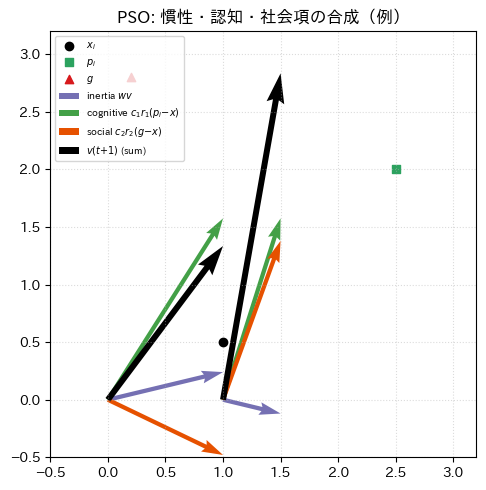

In [2]:
"""PSO 速度更新のベクトル分解を示す静止図。"""

import matplotlib.pyplot as plt
import numpy as np

try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    pass

x = np.array([1.0, 0.5])
p_i = np.array([2.5, 2.0])
g = np.array([0.2, 2.8])
v = np.array([0.4, -0.2])
w, c1, c2 = 0.6, 1.5, 1.5
r1, r2 = 0.7, 0.4

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(*x.T, color="k", zorder=5, label=r"$x_i$")
ax.scatter(*p_i.T, color="#2ca25f", marker="s", label=r"$p_i$")
ax.scatter(*g.T, color="#d7191c", marker="^", label=r"$g$")
origin = np.zeros(2)
ax.quiver(
    *[x],
    *[w * v],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#7570b3",
    width=0.01,
    label=r"inertia $w v$",
)
ax.quiver(
    *[x],
    *[c1 * r1 * (p_i - x)],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#43a047",
    width=0.01,
    label=r"cognitive $c_1 r_1 (p_i{-}x)$",
)
ax.quiver(
    *[x],
    *[c2 * r2 * (g - x)],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#e65100",
    width=0.01,
    label=r"social $c_2 r_2 (g{-}x)$",
)
sum_vec = (w * v) + c1 * r1 * (p_i - x) + c2 * r2 * (g - x)
ax.quiver(
    *[x],
    *[sum_vec],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#000",
    width=0.014,
    label=r"$v(t{+}1)$ (sum)",
)
ax.set_aspect("equal")
ax.set_xlim(-0.5, 3.2)
ax.set_ylim(-0.5, 3.2)
ax.grid(True, linestyle=":", alpha=0.45)
ax.legend(loc="upper left", fontsize=7)
ax.set_title("PSO: 慣性・認知・社会項の合成（例）")
plt.tight_layout()
plt.show()


### 3.6 アニメーション（2次元：Sphere 関数）

**Sphere 関数** $f(\boldsymbol{x}) = \|\boldsymbol{x}\|_2^2 = x_1^2 + x_2^2$ は、原点が唯一の大域最適（最小値 0）である **最もわかりやすいテスト関数** のひとつである。等高線は同心円になり、粒子群が **中心へ寄っていく** 様子が視覚的に追いやすい。

次のコードセルでは、複数粒子の軌跡と、各ステップでの **グローバルベスト**（赤い星）を表示する。パラメータ $w, c_1, c_2$ や粒子数を変えると、寄り方（速さ・振動）が変わるので、[jkushida のページにあるインタラクティブシミュレータ](https://jkushida.github.io/ai-arch/docs/pso_summary.html) の感覚とあわせて比較してもよい。

表示されない場合は、セルをもう一度上から実行し直す。ブラウザの JavaScript が有効である必要がある。

---


(sec:pso-sec37)=

### 3.7 PSO の長所と短所（使うときの注意）

[jkushida のまとめ](https://jkushida.github.io/ai-arch/docs/pso_summary.html) に沿って、実用上よく言及される点だけを短く整理する。

**長所の例**

- **実装が比較的簡単**で、1 ステップの更新計算も軽いことが多い。
- **勾配が不要**なので、目的関数がごつごつしていても適用しやすい。
- **多点探索＋gbest 共有**により、単一点法より局所解に閉じ込められにくい **こともある**。

**短所・注意の例**

- **パラメータ依存**が強く、$w, c_1, c_2, N$ の選び方で性能が大きく変わる。
- 問題が **高次元・多峰性** のとき、収束が遅い、または集団が **同じ谷に張り付く** ことがある。
- 厳密な **大域最適性の保証** を一般に持ちにくい（メタヒューリスティクス共通の注意）。

このため、PSO は「万能ソルバ」ではなく、**ベースラインや他手法との併用・ハイブリッド** の文脈で使われることも多い。

---


In [3]:
"""2次元 Sphere 関数上の単純 PSO と matplotlib アニメーション。"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation

try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    pass


def sphere(z: np.ndarray) -> np.ndarray:
    """形状 (2, n) の位置列に対する Sphere 値 f = sum(z*z, axis=0)。"""
    return np.sum(z * z, axis=0)


def run_pso_2d(
    n_particles: int,
    n_steps: int,
    seed: int,
    w: float,
    c1: float,
    c2: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    lim = 3.0
    x = rng.uniform(-lim, lim, size=(2, n_particles))
    v = rng.uniform(-0.5, 0.5, size=(2, n_particles))
    pbest = x.copy()
    g_idx = int(np.argmin(sphere(pbest)))
    g = pbest[:, g_idx : g_idx + 1].copy()
    hist_x = np.zeros((n_steps + 1, 2, n_particles))
    hist_g = np.zeros((n_steps + 1, 2))
    hist_x[0] = x
    hist_g[0, :] = g.ravel()
    for _t in range(n_steps):
        r1 = rng.random((2, n_particles))
        r2 = rng.random((2, n_particles))
        v = w * v + c1 * r1 * (pbest - x) + c2 * r2 * (g - x)
        x = x + v
        fx = sphere(x)
        fpb = sphere(pbest)
        better = fx < fpb
        pbest[:, better] = x[:, better]
        best_i = int(np.argmin(sphere(pbest)))
        g = pbest[:, best_i : best_i + 1]
        hist_x[_t + 1] = x
        hist_g[_t + 1, :] = g.ravel()
    return hist_x, hist_g, np.array([lim, lim]), g


hist_x, hist_g, lim_vec, _ = run_pso_2d(
    n_particles=25, n_steps=60, seed=7, w=0.72, c1=1.6, c2=1.6
)
lim = float(lim_vec[0])
grid = np.linspace(-lim, lim, 80)
X, Y = np.meshgrid(grid, grid)
Z = X * X + Y * Y

fig, ax = plt.subplots(figsize=(6, 5))
cont = ax.contourf(X, Y, Z, levels=20, cmap="viridis", alpha=0.85)
fig.colorbar(cont, ax=ax, label=r"$f(x,y)=x^2+y^2$")
scat = ax.scatter(hist_x[0, 0], hist_x[0, 1], c="white", edgecolors="k", s=45, zorder=6)
(g_line,) = ax.plot([], [], "r*", markersize=14, label=r"$g$ (global best)")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.set_title("PSO on Sphere (animation)")
ax.legend(loc="upper right")


def init() -> tuple:
    scat.set_offsets(hist_x[0].T)
    g_line.set_data([hist_g[0, 0]], [hist_g[0, 1]])
    return scat, g_line


def update(frame: int) -> tuple:
    scat.set_offsets(hist_x[frame].T)
    g_line.set_data([hist_g[frame, 0]], [hist_g[frame, 1]])
    return scat, g_line


anim = animation.FuncAnimation(
    fig,
    update,
    frames=hist_x.shape[0],
    init_func=init,
    interval=90,
    blit=True,
)
plt.close(fig)
HTML(anim.to_jshtml())


(sec:pso-pyswarms)=

### 3.8 実験：PySwarms による特徴選択（Wine データセットと SVM）

ここでは **連続ベクトルの位置** ではなく、各次元が $0$ または $1$ である **二値ベクトル** を粒子として扱う **Binary PSO** を、ライブラリ [PySwarms](https://pyswarms.readthedocs.io/en/latest/) の `BinaryPSO` で実行する。解決したいタスクは、`scikit-learn` の **Wine** データセットを **RBF カーネル SVM** で多クラス分類するときに、**どの特徴量を採用するか** を選ぶことである。

各粒子のベクトルは長さ $d=13$（Wine の特徴数）で、成分 $1$ はその特徴を採用、$0$ は捨てる、と解釈する。**目的関数**（最小化）は、各候補に対して **標準化 → SVC（RBF）→ 層化 5-fold CV** で得た平均精度 `acc` に対して $1-\mathrm{acc}$ とする。採用特徴が 0 本のときは目的値 $1$ のペナルティとする。

PySwarms の `BinaryPSO` は内部で **近傍（ring）トポロジー** を用いる。`options` の `k` は近傍幅であり、**粒子数より小さい値** に取る必要がある（大きすぎるとエラーになる）。反復数や粒子数を増やすと目的関数の評価回数が増え、**SVM の学習回数に比例して時間がかかる** 点に注意する。

下のセルを実行すると、最良粒子に対応する特徴の集合・CV 精度、および **反復ごとの大域最良コスト** と **特徴のオン／オフ** の棒グラフが表示される。

Google Colab などでこのセルを単体で試す場合は、環境に `pyswarms` が無ければ `pip install pyswarms` で追加する（本リポジトリでは `pyproject.toml` の依存に含めてある）。



最終の大域最良コスト（1 - 精度）: 0.0056
CV 平均精度（全特徴）: 0.9833
CV 平均精度（PSO 選択）: 0.9944
採用特徴数: 9 / 13
採用した特徴: ['alcohol', 'ash', 'alcalinity_of_ash', 'magnesium', 'flavanoids', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


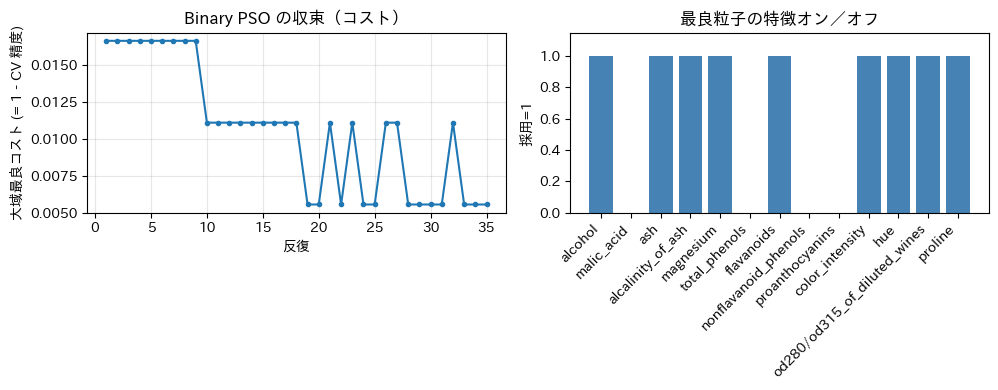

In [4]:
"""Wine データセット上で SVM の特徴選択を Binary PSO（PySwarms）で行うデモ。"""

from __future__ import annotations

from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
from pyswarms.discrete.binary import BinaryPSO
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 日本語ラベルを可能なら有効にする（プロジェクト依存: matplotlib-fontja）
try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    plt.rcParams["font.family"] = "sans-serif"


def make_objective(
    X: np.ndarray,
    y: np.ndarray,
    *,
    n_splits: int = 5,
) -> Callable[..., np.ndarray]:
    """特徴行列に対する Binary PSO 用目的関数を返す。"""

    def objective(swarm: np.ndarray, **kwargs: object) -> np.ndarray:
        """各粒子（二値ベクトル行）に対するコスト 1 - CV 平均精度を返す。"""
        n_particles = swarm.shape[0]
        costs = np.empty(n_particles, dtype=float)
        for i in range(n_particles):
            mask = swarm[i].astype(bool)
            if not mask.any():
                costs[i] = 1.0
                continue
            X_i = X[:, mask]
            pipe = Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale")),
                ]
            )
            scores = cross_val_score(
                pipe,
                X_i,
                y,
                cv=n_splits,
                scoring="accuracy",
            )
            costs[i] = 1.0 - float(np.mean(scores))
        return costs

    return objective


def run_feature_selection_pso(
    *,
    n_particles: int = 24,
    iters: int = 35,
    n_splits: int = 5,
    seed: int = 7,
) -> tuple[np.ndarray, float, BinaryPSO, list[str], np.ndarray, np.ndarray]:
    """Binary PSO で特徴選択を行い、最良マスクと optimizer 等を返す。"""
    wine = load_wine()
    X = np.asarray(wine.data, dtype=float)
    y = np.asarray(wine.target, dtype=int)
    feature_names = list(wine.feature_names)
    n_features = X.shape[1]
    objective = make_objective(X, y, n_splits=n_splits)

    rng = np.random.default_rng(seed)
    init = rng.integers(0, 2, size=(n_particles, n_features), dtype=int)

    k_neighbors = min(3, max(1, n_particles - 1))
    options = {"c1": 0.5, "c2": 0.5, "w": 0.9, "k": k_neighbors, "p": 2}
    optimizer = BinaryPSO(
        n_particles=n_particles,
        dimensions=n_features,
        options=options,
        init_pos=init,
    )
    best_cost, best_mask = optimizer.optimize(objective, iters=iters, verbose=False)
    return best_mask, float(best_cost), optimizer, feature_names, X, y


def plot_results(
    optimizer: BinaryPSO,
    best_mask: np.ndarray,
    feature_names: list[str],
    X: np.ndarray,
    y: np.ndarray,
    *,
    n_splits: int = 5,
) -> None:
    """大域最良コストの推移と、最良マスクの可視化。"""
    mask = best_mask.astype(bool)
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="rbf", C=1.0, gamma="scale")),
        ]
    )
    baseline = float(
        np.mean(cross_val_score(pipe, X, y, cv=n_splits, scoring="accuracy"))
    )
    selected = float(
        np.mean(
            cross_val_score(
                pipe, X[:, mask], y, cv=n_splits, scoring="accuracy"
            )
        )
    )

    print(f"CV 平均精度（全特徴）: {baseline:.4f}")
    print(f"CV 平均精度（PSO 選択）: {selected:.4f}")
    print(f"採用特徴数: {int(mask.sum())} / {X.shape[1]}")
    print("採用した特徴:", [n for n, m in zip(feature_names, mask) if m])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    hist = [float(x) for x in optimizer.cost_history]
    axes[0].plot(range(1, len(hist) + 1), hist, marker="o", ms=3)
    axes[0].set_xlabel("反復")
    axes[0].set_ylabel("大域最良コスト (= 1 - CV 精度)")
    axes[0].set_title("Binary PSO の収束（コスト）")
    axes[0].grid(True, alpha=0.3)

    xpos = np.arange(len(feature_names))
    axes[1].bar(xpos, mask.astype(int), color="steelblue")
    axes[1].set_xticks(xpos)
    axes[1].set_xticklabels(feature_names, rotation=45, ha="right")
    axes[1].set_ylim(0, 1.15)
    axes[1].set_ylabel("採用=1")
    axes[1].set_title("最良粒子の特徴オン／オフ")

    fig.tight_layout()
    plt.show()


def main() -> None:
    best_mask, best_cost, optimizer, names, X, y = run_feature_selection_pso()
    print(f"最終の大域最良コスト（1 - 精度）: {best_cost:.4f}")
    plot_results(optimizer, best_mask, names, X, y)


if __name__ == "__main__":
    main()


(sec:pso-knapsack)=

### 3.9 実験：PySwarms による 0-1 ナップザック問題

[3.8 節](#sec-pso-pyswarms) と同様に **二値ベクトル** を粒子とみなし、`BinaryPSO` で **0-1 ナップザック** を扱う。各次元 $i$ は品物 $i$ を **入れる（1）／入れない（0）** を表し、重量ベクトル $\boldsymbol{w}$、価値ベクトル $\boldsymbol{v}$、容量 $W$ に対して制約は $\boldsymbol{w}^\top \boldsymbol{x} \le W$、最大化したいのは $\boldsymbol{v}^\top \boldsymbol{x}$ である。

PySwarms は **最小化** を前提とするため、**実行可能解**（重量制約を満たす解）ではコストを $-\boldsymbol{v}^\top \boldsymbol{x}$ とし、**不可行解** では大きな正のペナルティを与える。これにより、粒子群は可行解の中で価値の大きい解を探しにいく。

下のセルでは、品物数 $n=10$ の小さな整数例を用いる（乱数シードで再現可能）。**厳密最適値** は総当たりで求め、PSO の結果と比較できるようにしてある。計算は軽いが、インスタンスや粒子数を大きくすると目的関数の評価回数が増える点には注意する。

前節と同様、環境に `pyswarms` が無い場合は `pip install pyswarms` で追加する。


In [ ]:
"""0-1 ナップザックを Binary PSO（PySwarms）で解くデモ。"""

from __future__ import annotations

from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
from pyswarms.discrete.binary import BinaryPSO

try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    plt.rcParams["font.family"] = "sans-serif"


def make_knapsack_objective(
    weights: np.ndarray,
    values: np.ndarray,
    capacity: float,
    *,
    penalty: float = 1e6,
) -> Callable[..., np.ndarray]:
    """可行なら価値のマイナス、不可行ならペナルティを返す目的関数を返す。"""

    def objective(swarm: np.ndarray, **kwargs: object) -> np.ndarray:
        """各粒子（二値行）に対するコストを返す。"""
        n_particles = swarm.shape[0]
        costs = np.empty(n_particles, dtype=float)
        w = weights.astype(float)
        v = values.astype(float)
        for i in range(n_particles):
            x = swarm[i].astype(float)
            w_sum = float(np.dot(w, x))
            v_sum = float(np.dot(v, x))
            if w_sum <= capacity:
                costs[i] = -v_sum
            else:
                costs[i] = penalty + w_sum
        return costs

    return objective


def brute_opt(
    weights: np.ndarray,
    values: np.ndarray,
    capacity: float,
) -> tuple[np.ndarray, float, float]:
    """総当たりで最適解（二値ベクトル・価値・重量）を返す。"""
    n = weights.size
    best_x = np.zeros(n, dtype=int)
    best_val = -1.0
    best_w = 0.0
    for mask in range(1 << n):
        x = np.array([(mask >> j) & 1 for j in range(n)], dtype=int)
        w_sum = float(np.dot(weights, x))
        v_sum = float(np.dot(values, x))
        if w_sum <= capacity and v_sum > best_val:
            best_val = v_sum
            best_x = x.copy()
            best_w = w_sum
    return best_x, best_val, best_w


def run_knapsack_pso(
    weights: np.ndarray,
    values: np.ndarray,
    capacity: float,
    *,
    n_particles: int = 28,
    iters: int = 40,
    seed: int = 11,
) -> tuple[np.ndarray, float, BinaryPSO]:
    """Binary PSO を走らせ、最良二値ベクトル・最良コスト・optimizer を返す。"""
    n = weights.size
    objective = make_knapsack_objective(weights, values, capacity)
    rng = np.random.default_rng(seed)
    init = rng.integers(0, 2, size=(n_particles, n), dtype=int)

    k_neighbors = min(3, max(1, n_particles - 1))
    options = {"c1": 0.5, "c2": 0.5, "w": 0.9, "k": k_neighbors, "p": 2}
    optimizer = BinaryPSO(
        n_particles=n_particles,
        dimensions=n,
        options=options,
        init_pos=init,
    )
    best_cost, best_x = optimizer.optimize(objective, iters=iters, verbose=False)
    return best_x.astype(int), float(best_cost), optimizer


def plot_knapsack_results(
    optimizer: BinaryPSO,
    best_x: np.ndarray,
    weights: np.ndarray,
    values: np.ndarray,
    capacity: float,
    opt_x: np.ndarray,
    opt_val: float,
) -> None:
    """コスト履歴と、最良解・厳密解の比較図を表示する。"""
    w_pso = float(np.dot(weights, best_x))
    v_pso = float(np.dot(values, best_x))
    w_opt = float(np.dot(weights, opt_x))
    print(f"厳密最適 価値={opt_val:.1f}, 重量={w_opt:.1f} / 容量={capacity:.1f}")
    print(f"PSO 最良 価値={v_pso:.1f}, 重量={w_pso:.1f} (可行: {w_pso <= capacity})")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    hist = [float(c) for c in optimizer.cost_history]
    axes[0].plot(range(1, len(hist) + 1), hist, marker="o", ms=3)
    axes[0].set_xlabel("反復")
    axes[0].set_ylabel("大域最良コスト（可行なら -価値）")
    axes[0].set_title("Binary PSO（ナップザック）")
    axes[0].grid(True, alpha=0.3)

    idx = np.arange(best_x.size)
    width = 0.35
    axes[1].bar(idx - width / 2, opt_x, width, label="厳密最適", color="gray")
    axes[1].bar(idx + width / 2, best_x, width, label="PSO 最良", color="coral")
    axes[1].set_xticks(idx)
    axes[1].set_xticklabels([str(i) for i in idx])
    axes[1].set_xlabel("品物 index")
    axes[1].set_ylabel("選択 0/1")
    axes[1].set_title("品物の入れ方（厳密 vs PSO）")
    axes[1].legend()
    axes[1].set_ylim(-0.1, 1.15)

    fig.tight_layout()
    plt.show()


def main() -> None:
    rng = np.random.default_rng(42)
    n = 10
    weights = rng.integers(1, 15, size=n)
    values = rng.integers(5, 40, size=n)
    capacity = float(int(0.45 * weights.sum()))

    opt_x, opt_val, _ = brute_opt(weights, values, capacity)
    best_x, best_cost, optimizer = run_knapsack_pso(
        weights, values, capacity
    )
    print(f"最終の大域最良コスト: {best_cost:.4f}")
    plot_knapsack_results(
        optimizer, best_x, weights, values, capacity, opt_x, opt_val
    )


if __name__ == "__main__":
    main()


(sec:pso-svm-hyper)=

### 3.10 実験：連続 PSO（GlobalBestPSO）による Wine・SVM のハイパーパラメータ探索

[3.8 節](#sec-pso-pyswarms) では **二値ベクトル** と `BinaryPSO` で **特徴のオン／オフ** を選んだ。ここでは **連続 2 次元ベクトル** を粒子の位置とみなし、PySwarms の **`GlobalBestPSO`**（標準的な **慣性重み付き PSO** の大域版）で、**RBF カーネル SVM** の **$C$** と **$\gamma$** を同時に調整する。

具体的には、粒子の座標を $(x_1, x_2) = (\log_{10} C,\; \log_{10}\gamma)$ とおき、探索境界（上下限）の箱の中で粒子を動かす。目的関数（最小化）は、**全特徴を用いた** `StandardScaler` + `SVC` に対する **層化 5-fold CV の平均精度** `acc` に対して $1-\\mathrm{acc}$ とする（3.8 の離散例と同型の「誤り率」的コスト）。

これは [アルゴリズムの流れ（全体像）](#sec-pso-flow) の式 (1)(2) が表す **連続 PSO** に相当し、`BinaryPSO` の **シグモイドによる二値化** は行わない点が対照的である。`pyswarms` は既に [3.8](#sec-pso-pyswarms)・[3.9](#sec-pso-knapsack) で利用している。

前節どおり、環境に `pyswarms` が無い場合は `pip install pyswarms` で追加する。


In [ ]:
"""Wine 上で SVM の (C, gamma) を GlobalBestPSO（連続 PSO）で探索するデモ。"""

from __future__ import annotations

from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
from pyswarms.single.global_best import GlobalBestPSO
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    plt.rcParams["font.family"] = "sans-serif"


def make_hyper_objective(
    X: np.ndarray,
    y: np.ndarray,
    *,
    n_splits: int = 5,
) -> Callable[..., np.ndarray]:
    """(log10 C, log10 gamma) に対する CV 誤り率 1 - acc を返す目的関数を返す。"""

    def objective(swarm: np.ndarray, **kwargs: object) -> np.ndarray:
        """各粒子（行が log10 C, log10 gamma）のコストを返す。"""
        n = swarm.shape[0]
        costs = np.empty(n, dtype=float)
        for i in range(n):
            log_c = float(swarm[i, 0])
            log_g = float(swarm[i, 1])
            c_val = 10.0**log_c
            g_val = 10.0**log_g
            pipe = Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("svc", SVC(kernel="rbf", C=c_val, gamma=g_val)),
                ]
            )
            scores = cross_val_score(
                pipe,
                X,
                y,
                cv=n_splits,
                scoring="accuracy",
            )
            costs[i] = 1.0 - float(np.mean(scores))
        return costs

    return objective


def baseline_accuracy(
    X: np.ndarray,
    y: np.ndarray,
    *,
    n_splits: int = 5,
) -> float:
    """sklearn 既定に近い C=1, gamma='scale' の CV 平均精度。"""
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="rbf", C=1.0, gamma="scale")),
        ]
    )
    return float(np.mean(cross_val_score(pipe, X, y, cv=n_splits)))


def run_hyper_pso(
    X: np.ndarray,
    y: np.ndarray,
    *,
    n_particles: int = 28,
    iters: int = 40,
    seed: int = 19,
) -> tuple[np.ndarray, float, GlobalBestPSO]:
    """GlobalBestPSO を実行し、最良位置・最良コスト・optimizer を返す。"""
    min_b = np.array([-2.0, -4.0], dtype=float)
    max_b = np.array([3.0, 1.0], dtype=float)
    bounds = (min_b, max_b)
    objective = make_hyper_objective(X, y, n_splits=5)
    options = {"c1": 0.5, "c2": 0.5, "w": 0.72}
    optimizer = GlobalBestPSO(
        n_particles=n_particles,
        dimensions=2,
        options=options,
        bounds=bounds,
    )
    rng = np.random.default_rng(seed)
    low, high = bounds[0], bounds[1]
    init = rng.uniform(low, high, size=(n_particles, 2))
    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=iters,
        init_pos=init,
        verbose=False,
    )
    return best_pos.astype(float), float(best_cost), optimizer


def plot_hyper_results(
    optimizer: GlobalBestPSO,
    best_pos: np.ndarray,
    base_acc: float,
    objective: Callable[..., np.ndarray],
) -> None:
    """大域最良コストの推移と、終了時粒子の散布図を描く。"""
    log_c, log_g = float(best_pos[0]), float(best_pos[1])
    c_fin, g_fin = 10.0**log_c, 10.0**log_g
    best_acc = 1.0 - float(optimizer.swarm.best_cost)

    print(f"ベースライン（C=1, gamma='scale'）CV 精度: {base_acc:.4f}")
    print(
        f"PSO 最良: log10 C={log_c:.3f}, log10 gamma={log_g:.3f} "
        f"=> C={c_fin:.4g}, gamma={g_fin:.4g}, CV 精度={best_acc:.4f}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    hist = [float(x) for x in optimizer.cost_history]
    axes[0].plot(range(1, len(hist) + 1), hist, marker="o", ms=3)
    axes[0].axhline(1.0 - base_acc, color="gray", ls="--", lw=1, label="ベースライン")
    axes[0].set_xlabel("反復")
    axes[0].set_ylabel("大域最良コスト (= 1 - CV 精度)")
    axes[0].set_title("GlobalBestPSO（連続）")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    pos = np.asarray(optimizer.swarm.position, dtype=float)
    costs = objective(pos)
    sc = axes[1].scatter(pos[:, 0], pos[:, 1], c=costs, cmap="viridis", s=45)
    axes[1].scatter(
        [best_pos[0]],
        [best_pos[1]],
        marker="*",
        s=220,
        c="red",
        edgecolors="k",
        zorder=5,
        label="大域最良",
    )
    plt.colorbar(sc, ax=axes[1], label="コスト")
    axes[1].set_xlabel(r"$\log_{10} C$")
    axes[1].set_ylabel(r"$\log_{10}\gamma$")
    axes[1].set_title("終了時の粒子（色=コスト）")
    axes[1].legend()

    fig.tight_layout()
    plt.show()


def main() -> None:
    wine = load_wine()
    X = np.asarray(wine.data, dtype=float)
    y = np.asarray(wine.target, dtype=int)
    base_acc = baseline_accuracy(X, y)
    obj = make_hyper_objective(X, y)
    best_pos, best_cost, optimizer = run_hyper_pso(X, y)
    print(f"最終の大域最良コスト: {best_cost:.4f}")
    plot_hyper_results(optimizer, best_pos, base_acc, obj)


if __name__ == "__main__":
    main()


(sec:pso-sec311)=

### 3.11 PSOアルゴリズム：日本語まとめ

---

#### 基本的な考え方

PSOは，解の候補を **粒子** と呼ぶ点として扱い，複数の粒子を同時に動かして最適解を探す **多点探索メタヒューリスティクス** である．各粒子は「自分の過去最良位置」と「群れ全体の最良位置」の両方を参照して移動方向を決める．

---

#### 粒子が持つ情報

| 変数 | 意味 |
| --- | --- |
| $\boldsymbol{x}_i^{(t)}$ | ステップ $t$ での **位置**（＝現在の候補解） |
| $\boldsymbol{v}_i^{(t)}$ | ステップ $t$ での **速度**（＝次の移動量） |
| $\boldsymbol{p}_i$ | 粒子 $i$ が過去に訪れた **最良位置**（パーソナルベスト） |
| $\boldsymbol{g}$ | 全粒子中で最良だった位置（**グローバルベスト**） |

---

#### アルゴリズムの流れ

**Step 1：初期化**

- 各粒子の位置 $\boldsymbol{x}_i$ と速度 $\boldsymbol{v}_i$ を探索空間内でランダムに設定する．
- 初期位置をそのまま $\boldsymbol{p}_i$ とし，全粒子中の最良を $\boldsymbol{g}$ とする．

**Step 2：速度の更新**

$$
\boldsymbol{v}_i^{(t+1)} = \underbrace{\omega\,\boldsymbol{v}_i^{(t)}}_{\text{慣性項}}
+ \underbrace{c_1\,\boldsymbol{r}_1 \odot (\boldsymbol{p}_i - \boldsymbol{x}_i^{(t)})}_{\text{認知項（自己記憶）}}
+ \underbrace{c_2\,\boldsymbol{r}_2 \odot (\boldsymbol{g} - \boldsymbol{x}_i^{(t)})}_{\text{社会項（群れの知見）}}
$$

- **慣性項**：直前の速度をそのまま引き継ぐ．$\omega$ が大きいと広い探索（exploration）を促す．
- **認知項**：自分のパーソナルベストへ引き寄せる．$c_1$ が大きいと個体の経験を重視する．
- **社会項**：グローバルベストへ引き寄せる．$c_2$ が大きいと群れの情報に従いやすくなる．
- $\boldsymbol{r}_1, \boldsymbol{r}_2$ は $[0,1]$ の一様乱数ベクトルで，確率的なばらつきを与える．

**Step 3：位置の更新**

$$
\boldsymbol{x}_i^{(t+1)} = \boldsymbol{x}_i^{(t)} + \boldsymbol{v}_i^{(t+1)}
$$

**Step 4：パーソナルベスト／グローバルベストの更新**

- $f(\boldsymbol{x}_i^{(t+1)}) < f(\boldsymbol{p}_i)$ ならば $\boldsymbol{p}_i \leftarrow \boldsymbol{x}_i^{(t+1)}$
- 全粒子の $\boldsymbol{p}_i$ を比較して $\boldsymbol{g}$ を更新する．

**Step 5：終了判定**

- 最大反復数に達したか，$f(\boldsymbol{g})$ の改善が止まったら終了し，$\boldsymbol{g}$ を解として出力する．

---

#### 三項のベクトル合成イメージ

[3.5節「図：三つのベクトルが合成される様子」](#sec-pso-sec35) のコードが示すように，新しい速度は3本の矢印（慣性・認知・社会）を **ベクトル加算** したものである．それぞれが引っ張る方向と大きさのバランスが，粒子の軌道を決める．

---

#### 主なパラメータの目安

| パラメータ | 役割 | よく使われる値 |
| --- | --- | --- |
| $N$（粒子数） | 多点探索の幅 | 20〜50 |
| $\omega$（慣性重み） | 探索と開拓のバランス | 0.4〜0.9（線形減少も一般的） |
| $c_1$（認知係数） | 自己記憶への引力 | 2.0前後 |
| $c_2$（社会係数） | 群れの知見への引力 | 2.0前後 |

---

#### 注意点

- 勾配不要でブラックボックス最適化に向くが，**大域最適性の保証はない**．
- 多峰性の強い問題では，粒子群が同じ谷に固まり（**早期収束**）局所最適に陥りやすい．
- $\boldsymbol{g}$ が一つの谷に固まると，全粒子が社会項によってそこへ引き寄せられるため，脱出が難しくなる（確認問題3の要点）．

---


## 4. 確認問題

1. 式 (1) のうち、**集団全体で共有されている情報** に直接対応するのはどの項か。記号で答えよ。
2. $\omega$（$w$）を大きくした場合と小さくした場合で、探索と開拓の **どちらが強まりやすいか** を、自分の言葉で説明せよ。
3. 目的関数が **多峰性** のとき、粒子群が一つの谷に集まりすぎると何が起こりやすいか。式の構造（特に $\boldsymbol{g}$）に結びつけて述べよ。
4. ACO と PSO で、解の **表現** の典型例をそれぞれ一つずつ挙げよ。

### 参考リンク

- [粒子群最適化（PSO）— jkushida/ai-arch](https://jkushida.github.io/ai-arch/docs/pso_summary.html)（理論・パラメータ表・シミュレータ・PDF への入口）
- Kennedy と Eberhart による原論文・サーベイ（英語）
- 日本語の書籍・総説は [参考文献.md](参考文献.md) も参照のこと。

---
